In [1]:
!pip install shap

In [2]:
# Import required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, recall_score, precision_score, f1_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import PowerTransformer, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
import shap

# Hide warnings in the notebook
from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
test_url = 'https://raw.githubusercontent.com/Hertfordshire-Data-Science-Hackathon/Group-F-RMDS-Hackathon/refs/heads/main/dataset_A_testing.csv'


training_url = 'https://raw.githubusercontent.com/Hertfordshire-Data-Science-Hackathon/Group-F-RMDS-Hackathon/refs/heads/main/dataset_A_training.csv'

In [4]:
'''
  Import dataset for training and test for analysis
'''

# Training dataset
df_vaccine = pd.read_csv(training_url)

# Test dataset
df_vaccine_test = pd.read_csv(test_url)

In [5]:
df_vaccine.set_index('respondent_id', inplace=True)
df_vaccine_test.set_index('respondent_id', inplace=True)

In [6]:
# Preview
df_vaccine.sample(10)

,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_seasonal,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
respondent_id,,,,,,,,,,,,,,,,,,,,,
3323,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Employed,Non-MSA,1.0,2.0,construction,0
1953,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,NaN,1
1013,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,...,Male,"<= $75,000, Above Poverty",Married,Rent,Employed,"MSA, Principle City",1.0,2.0,construction,0
3487,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,"<= $75,000, Above Poverty",Not Married,Own,Employed,"MSA, Not Principle City",0.0,0.0,wholesale,0
1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
4356,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,Female,"> $75,000",Married,Own,Not in Labor Force,"MSA, Principle City",2.0,0.0,NaN,0
399,3.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,Female,"> $75,000",Not Married,Own,Employed,Non-MSA,2.0,3.0,healthcare,0
2208,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,...,Male,"> $75,000",Married,Own,Employed,"MSA, Principle City",1.0,0.0,wholesale,1
3679,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,0.0,healthcare,1


# **EDA and Pre-processing**

In [7]:
# seperate target from features
target = df_vaccine['seasonal_vaccine']
feature = df_vaccine.drop(columns=['seasonal_vaccine'], axis=1)

In [8]:
mice_imputer = IterativeImputer(random_state=42)
power_transformer = PowerTransformer(method="yeo-johnson")

In [9]:
# Separate numerical and categorical columns
numerical_cols = feature.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = feature.select_dtypes(include=["object", "category"]).columns

In [10]:
# Make column transformation
preprocessor = ColumnTransformer([
    ('imputer', mice_imputer, numerical_cols),
    ('transformer', power_transformer, numerical_cols),
    ('one-hot', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ], remainder = 'passthrough'
  )

In [11]:
# Define pipeline for sequencing
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier())
])

In [12]:
# Split dataset for model training
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size = 0.2, random_state=42)

In [13]:
# Create dictionary to store models
models = {
  'rfc': {
    'name':'Random Forest',
    'model': RandomForestClassifier(random_state=42),
    'params':{
      'model__n_estimators': [200,500],
      'model__max_depth': [15, 30],
      'model__min_samples_split': [2, 5],
      'model__min_samples_leaf': [2, 4],
      'model__max_features': ['sqrt', 'log2']
    }
  }
}


In [14]:
# Store f1-score of each tunned model for visualization
model_name = []
model_f1score = []

----------------------------------------------------------------------------------------------------
--> Random Forest <--
Best Estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer',
                                                  IterativeImputer(random_state=42),
                                                  Index(['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'd...
                                                 ('one-hot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_st

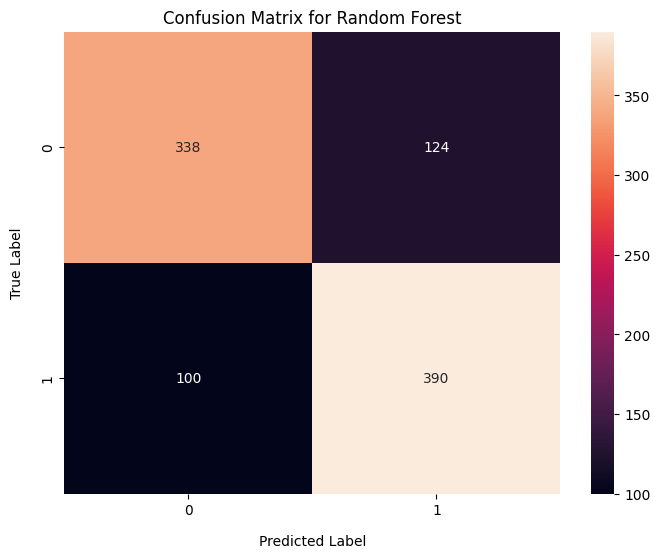

In [15]:
''' Training models by looping through the hyperparameter model dictionary while also outputing metrics'''

for abbr, model_dict in models.items():

  # Set the default model in the pipeline to the current running model
  pipeline.set_params(model = model_dict['model'])

  # Use the randomizedsearch CV to find the best model and perform the prediction
  model_search = RandomizedSearchCV(pipeline, model_dict['params'], n_iter=50,cv=5, scoring='f1', n_jobs=-1, random_state=42)

  # Fit data for training
  model_search.fit(X_train, y_train)

  # Find the best estimator from the randomizedsearchcv
  best_estimator = model_search.best_estimator_

  # Make prediction using
  y_pred = model_search.predict(X_test)
  y_pred_test = model_search.predict(df_vaccine_test)

  #-----------------------------------------------------------------

   # Store result of each model metrics for visualization
  model_name.append(model_dict['name'])
  model_f1score.append(f1_score(y_test,y_pred))

  # Get results to dataframe and save
  results = pd.DataFrame({
      'respondent_id' : df_vaccine_test.index,
      'seasonal_vaccine' : y_pred_test
  })

  results.to_csv(f'/content/{model_dict['name']}.csv', index=False)

  #-----------------------------------------------------------------

  # Show metrics
  print('-'*100)
  print(f'--> {model_dict['name']} <--')
  #print('\n')

  #Print the best estimator
  print(f'Best Estimator: {best_estimator}')

  print('-'*100)
  print(f'F1 score for {model_dict['name']}: {f1_score(y_test,y_pred)}')
  #-----------------------------------------------------------------

  # Print out the best parameter
  print('-'*100)
  print(f'--> Best paramter found for {model_dict['name']} --')
  print(best_estimator.named_steps['model'])

  # Add line break
  print('\n\n')

  # Plot the confusion matrix of the model
  cm = confusion_matrix(y_test,y_pred)
  plt.subplots(figsize=(8,6), dpi=100)
  sns.heatmap(cm,annot=True,fmt='d',cbar=True,)
  plt.xlabel('Predicted Label', labelpad=12)
  plt.ylabel('True Label', labelpad=12)
  plt.title(f'Confusion Matrix for {model_dict['name']}')
  plt.show()

  # Add line break
  print('\n\n')

# **Model Interpretability using SHAP**

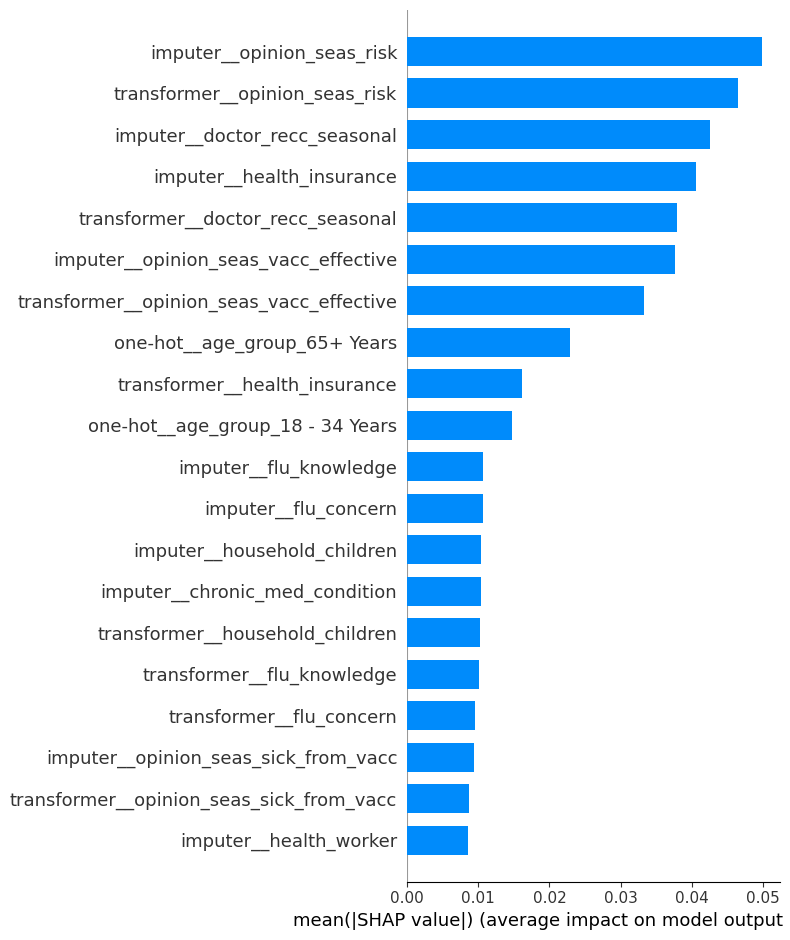

In [16]:
# Get fitted preprocessor from the pipeline
fitted_preprocessor = best_estimator.named_steps["preprocessor"]

# Get fitted model from the pipeline
fitted_model = best_estimator.named_steps["model"]

# Transform X_sample using the fitted preprocessor
X_transformed = fitted_preprocessor.transform(X_test)

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Convert transformed data to DataFrame
X_shap = pd.DataFrame(
    X_transformed,
    columns=feature_names,
    index=X_test.index
)

# Create SHAP explainer
explainer = shap.TreeExplainer(fitted_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

# For binary classification
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]

elif len(np.array(shap_values).shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]

else:
    shap_values_to_plot = shap_values

# SHAP bar plot
shap.summary_plot(
    shap_values_to_plot,
    X_shap,
    plot_type="bar",
    max_display=20
)

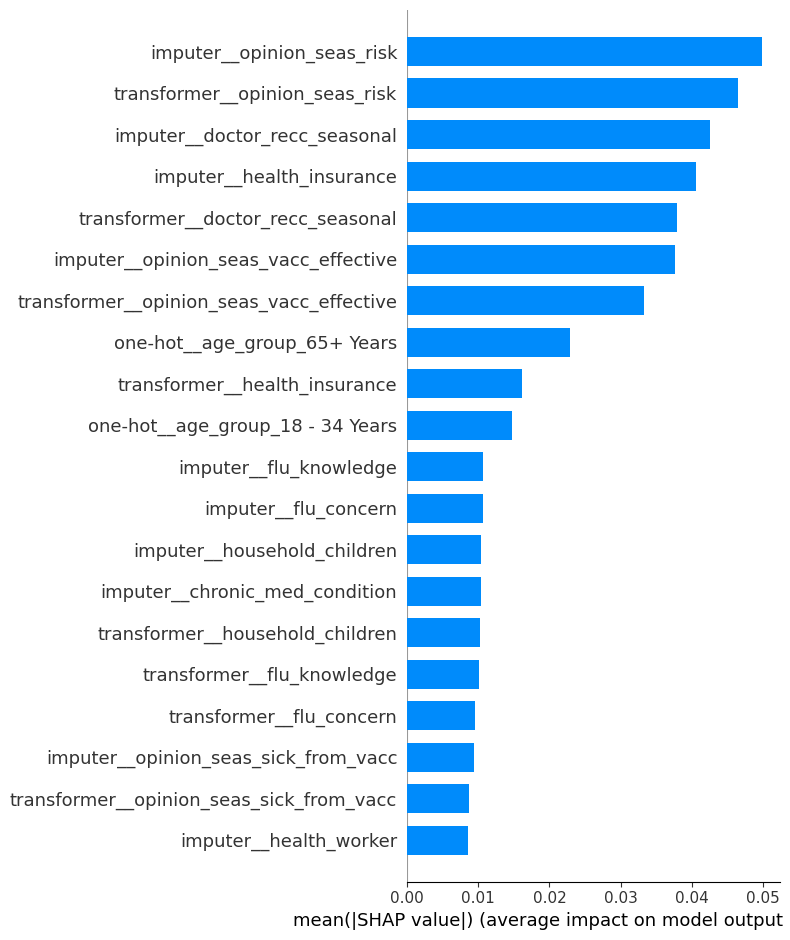

In [17]:
# SHAP bar plot
shap.summary_plot(
    shap_values_to_plot,
    X_shap,
    plot_type="bar",
    max_display=20
)

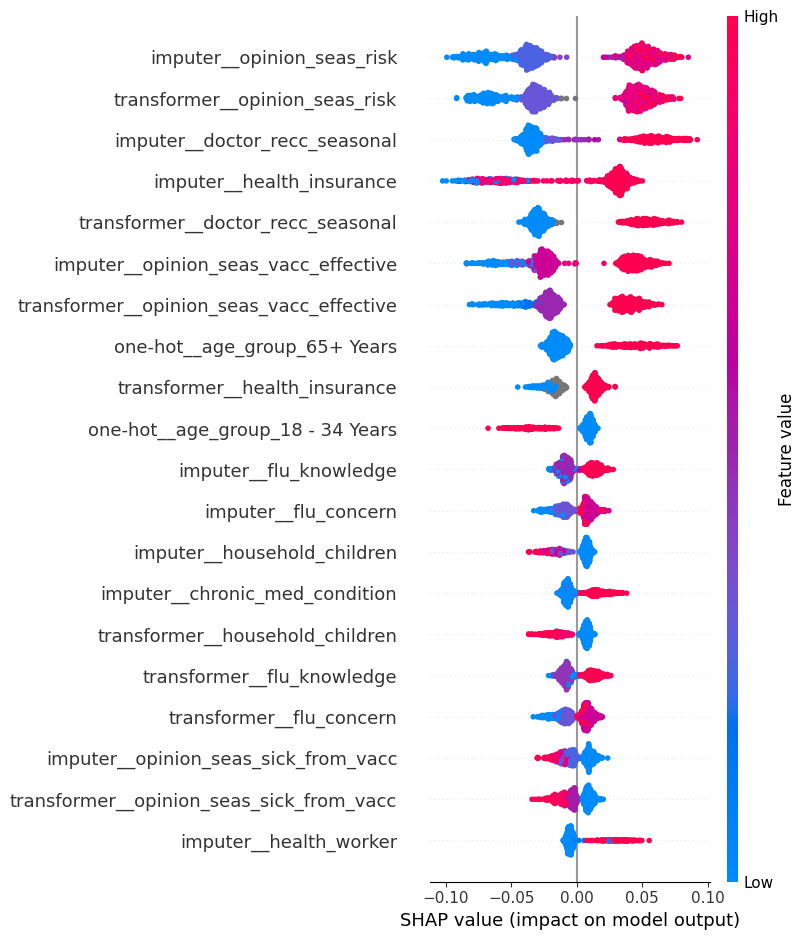

In [18]:
# SHAP beeswarm plot
shap.summary_plot(
    shap_values_to_plot,
    X_shap,
    max_display=20
)